In [1]:
# CIFAR10 dataset으로 분류기 작성 + CNN 레이어 추가
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape) # (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)

print(x_train[0])
print(y_train[0])

# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Onehot encoding
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

print(y_train.shape)
print(y_train[0])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]
(50000, 10)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [11]:
# 모델 정의
def conv_block(x, filters):
  x = layers.Conv2D(filters=filters, kernel_size=3, padding='same', use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)
  return x

inputs = layers.Input(shape=(32,32,3))

# Stage1
x = conv_block(inputs, 32)
x = conv_block(x, 32)
x = layers.MaxPool2D()(x)

# Stage2
x = conv_block(x, 64)
x = conv_block(x, 64)
x = layers.MaxPool2D()(x)

# Stage3
x = conv_block(x, 128)
x = conv_block(x, 128)
x = layers.MaxPool2D()(x)

# 분류기
x = layers.GlobalAveragePooling2D()(x)  # 4차원을 2차원으로 줄여주기 때문에 Flatten사용안함
# CNN의 마지막 conv 출력이(batch_size,w,w,c)형태 이를 채널 평균값을 하나씩 뽑는 방식 사용
# 장점 : 파라미터 수가 줄어준다. 과적합 방지에 효과적
x = layers.Dropout(0.2)(x)
x = layers.Dense(units=128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(units=10, activation='softmax')(x)

model = models.Model(inputs, outputs, name='cifar10_cnn')
print(model.summary())

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 306,154 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

None


In [12]:
# compile / fit
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
es = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

model.fit(x=x_train, y=y_train, batch_size=128, epochs=20, shuffle=True, verbose=2,
          validation_split=0.1,
          callbacks=[es])

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0, batch_size=128)
print('test acc : %.4f' % test_acc)
print('test loss : %.4f' % test_loss)

Epoch 1/20
352/352 - 23s - 64ms/step - accuracy: 0.4724 - loss: 1.4367 - val_accuracy: 0.3638 - val_loss: 2.1052
Epoch 2/20
352/352 - 5s - 14ms/step - accuracy: 0.6328 - loss: 1.0277 - val_accuracy: 0.4812 - val_loss: 1.6403
Epoch 3/20
352/352 - 5s - 15ms/step - accuracy: 0.6973 - loss: 0.8604 - val_accuracy: 0.5970 - val_loss: 1.1566
Epoch 4/20
352/352 - 5s - 15ms/step - accuracy: 0.7403 - loss: 0.7403 - val_accuracy: 0.6602 - val_loss: 0.9617
Epoch 5/20
352/352 - 5s - 14ms/step - accuracy: 0.7748 - loss: 0.6509 - val_accuracy: 0.6546 - val_loss: 1.0459
Epoch 6/20
352/352 - 5s - 15ms/step - accuracy: 0.7975 - loss: 0.5803 - val_accuracy: 0.7016 - val_loss: 0.8962
Epoch 7/20
352/352 - 5s - 15ms/step - accuracy: 0.8195 - loss: 0.5241 - val_accuracy: 0.7402 - val_loss: 0.7964
Epoch 8/20
352/352 - 5s - 15ms/step - accuracy: 0.8378 - loss: 0.4781 - val_accuracy: 0.6498 - val_loss: 1.0694
Epoch 9/20
352/352 - 5s - 15ms/step - accuracy: 0.8489 - loss: 0.4355 - val_accuracy: 0.7756 - val_loss

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
예측값 :  ['cat' 'automobile' 'ship' 'ship' 'frog' 'frog' 'truck' 'cat' 'cat'
 'automobile']
실제값 :  ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 :  4


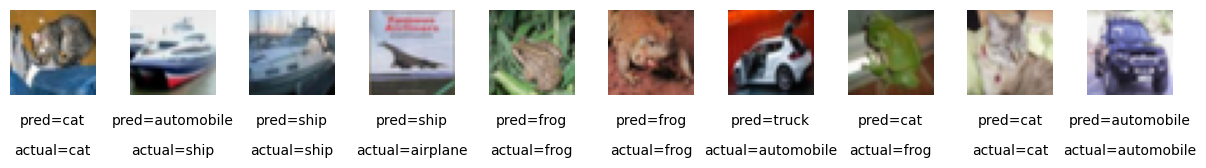

In [13]:
from matplotlib import transforms
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)]

actual = CLASSES[np.argmax(y_test[:10], axis=-1)]
print('예측값 : ', pred)
print('실제값 : ', actual)
print('분류 실패 수 : ', (pred != actual).sum())

# 시각화
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.4, wspace=0.4)   # subplot 사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
  img = x_test[idx]
  ax = fig.add_subplot(1, len(x_test[:10]), i + 1)
  ax.axis('off')
  ax.imshow(img)

  # transAxes: 이미지 픽셀 좌표 대신에 subplot 영역 기준 :0.5 - 가운데 정렬, 0.0 -왼쪽정렬, 1.0- 오른쪽정렬
  ax.text(0.5, -0.35, 'pred=' + str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
  ax.text(0.5, -0.7, 'actual=' + str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)

plt.show()
